# Daily ESP fields and a mean three-dimensional eddy

This notebook reconstructs the ESP velocity field independently for every selected day of one eddy, recentres each field on its shallowest fitted centre, and then composites the evaluated velocity fields. It does not average ESP parameters before reconstruction.

The default onshore frame rotates each day using the local core-mean bathymetric gradient: positive axis 1 is onshore and positive axis 2 is alongshore. This prevents southward translation and slow changes in shelf orientation from smearing a persistent cross-shelf tilt. The mean fitted centre line is shown relative to the shallow centre. Because the authoritative TiltDir points from deep to shallow, an onshore TiltDir generally corresponds to deeper fitted centres lying on the negative/offshore side of the composite.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subfolder.')
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
import esp_composite_tools as ect

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300})
pd.set_option('display.max_columns', 100)

## Controls

Start with one long-lived eddy. Use DAY_RANGE to isolate the southward shelf-following part of its life. Set MAXIMUM_BATHYMETRY_M, for example to 2500 m, if you want to retain only days whose surface centre lies over the shelf or slope.

In [2]:
EDDY_ID = 376
DAY_RANGE = (None, None)
MINIMUM_PROFILE_DEPTH_M = 500.0
MAXIMUM_BATHYMETRY_M = None

COMPOSITE_FRAME = 'onshore'  # 'onshore' or 'grid'
HORIZONTAL_UNITS = 'km'      # for 'Rc', also change HALF_WIDTH and GRID_STEP (e.g. 3 and 0.15)
HALF_WIDTH = 100.0
GRID_STEP = 5.0
MAXIMUM_DEPTH_M = 1000.0
MINIMUM_DEPTH_DAY_FRACTION = 0.70
DEPTH_LEVEL_INDICES = None   # e.g. (0, 4, 8, 12); None uses coverage threshold
ESP_ROOT = ect.DEFAULT_ESP_ROOT

## Load and filter one eddy

In [3]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface_df, _ = tilt.load_tilt_tables(paths)
vertical_df = tilt.load_vert(paths, dic_form=False)

surface, profiles = ect.select_eddy_days(
    surface_df, vertical_df, EDDY_ID,
    day_range=DAY_RANGE,
    minimum_profile_depth_m=MINIMUM_PROFILE_DEPTH_M,
    maximum_bathymetry_m=MAXIMUM_BATHYMETRY_M,
    grid=grid,
)
print(
    f'{surface.Cyc.iloc[0]}{EDDY_ID}: {surface.Day.nunique()} selected days, '
    f'days {surface.Day.min():g}–{surface.Day.max():g}'
)

CE376: 72 selected days, days 2618–2691


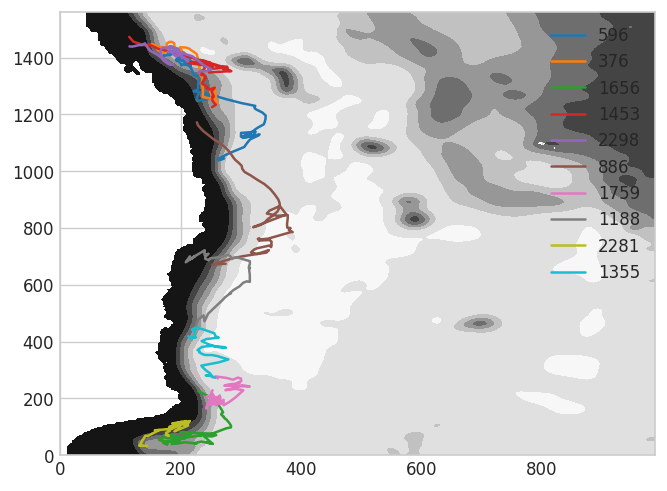

In [4]:
s1s2_eddies = np.array([596, 376, 1656, 1453, 2298, 886, 1759, 1188, 2281, 1355])
plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, grid.h/1e3, np.nan), cmap='Greys_r')
for eddy in s1s2_eddies:
    df = surface_df[surface_df.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=eddy)
plt.legend()

## Selected trajectory over bathymetry

Use this plot to refine DAY_RANGE before constructing the composite.

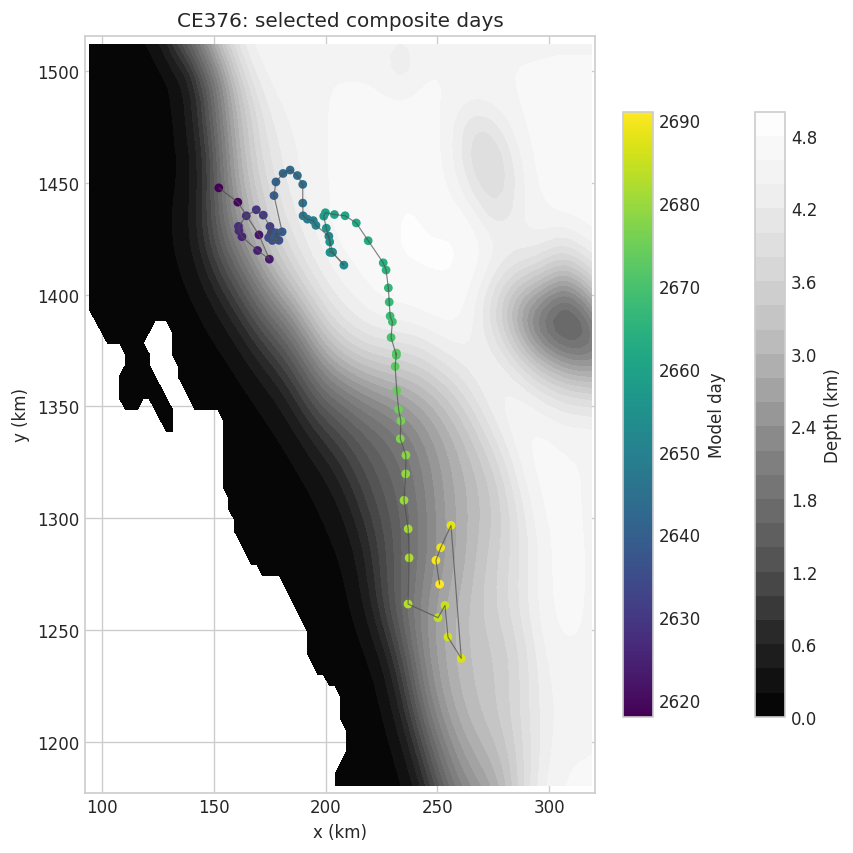

In [5]:
pad = 60
xmin, xmax = surface.xc.min()-pad, surface.xc.max()+pad
ymin, ymax = surface.yc.min()-pad, surface.yc.max()+pad
inside = (
    (grid.X_grid >= xmin) & (grid.X_grid <= xmax)
    & (grid.Y_grid >= ymin) & (grid.Y_grid <= ymax)
)
bathy = np.where((grid.mask_rho == 1) & inside, grid.h/1e3, np.nan)
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
mesh = ax.contourf(grid.X_grid, grid.Y_grid, bathy, levels=25, cmap='Greys_r')
fig.colorbar(mesh, ax=ax, label='Depth (km)', shrink=.8)
points = ax.scatter(surface.xc, surface.yc, c=surface.Day, cmap='viridis', s=18)
ax.plot(surface.xc, surface.yc, color='0.3', lw=.7, alpha=.7)
fig.colorbar(points, ax=ax, label='Model day', shrink=.8)
ax.set(
    xlim=(xmin, xmax), ylim=(ymin, ymax), xlabel='x (km)', ylabel='y (km)',
    title=f'{surface.Cyc.iloc[0]}{EDDY_ID}: selected composite days', aspect='equal',
)
plt.show()

## Select exact fitted depths

No vertical interpolation is used between ESP profiles. By default, a fixed depth is retained when it occurs on at least the requested fraction of selected days. Alternatively, choose exact rows using DEPTH_LEVEL_INDICES.

In [6]:
depth_catalogue = ect.depth_catalogue(profiles, MAXIMUM_DEPTH_M)
depths = ect.choose_depths(
    depth_catalogue,
    minimum_day_fraction=MINIMUM_DEPTH_DAY_FRACTION,
    depth_indices=DEPTH_LEVEL_INDICES,
)
depth_catalogue['selected'] = depth_catalogue.Depth.isin(depths)
display(depth_catalogue)
print('Selected exact depths:', ', '.join(f'{depth:g} m' for depth in depths))

,depth_index,Depth,days,fraction_of_days,selected
0,0,0.000000,72,1.000000,True
1,1,5.879627,72,1.000000,True
2,2,10.725783,72,1.000000,True
3,3,16.383097,72,1.000000,True
4,4,22.925581,72,1.000000,True
5,5,30.444118,72,1.000000,True
6,6,39.052712,72,1.000000,True
7,7,48.897638,72,1.000000,True
8,8,60.170639,72,1.000000,True
9,9,73.127842,72,1.000000,True


Selected exact depths: 0 m, 5.87963 m, 10.7258 m, 16.3831 m, 22.9256 m, 30.4441 m, 39.0527 m, 48.8976 m, 60.1706 m, 73.1278 m, 88.1168 m, 105.616 m, 126.288 m, 151.066 m, 181.265 m, 218.755 m, 266.206 m, 327.441 m, 407.922 m, 515.416 m, 660.806 m, 858.918 m


## Reconstruct every daily field and composite them

Each daily ESP field is evaluated on the same relative grid. The mean and standard deviation are accumulated without retaining every full daily volume, which keeps memory use modest for long-lived eddies.

In [7]:
composite = ect.build_eddy_composite(
    surface, profiles, grid, depths,
    frame=COMPOSITE_FRAME,
    half_width=HALF_WIDTH,
    grid_step=GRID_STEP,
    horizontal_units=HORIZONTAL_UNITS,
    esp_root=ESP_ROOT,
)
display(composite.daily)
display(pd.DataFrame({
    'Depth_m': composite.depths,
    'days_at_centre': composite.counts[:, len(composite.coordinate)//2, len(composite.coordinate)//2],
    'mean_axis1_offset': composite.centre_mean.axis1_offset,
    'mean_axis2_offset': composite.centre_mean.axis2_offset,
}))

,Eddy,Day,Cyc,axis1_bearing,bathymetry_gradient_m_per_m,levels_used,TiltDir,TiltDis,lat,lon,tilt_minus_axis1_deg
0,376,2618,CE,237.939717,0.037743,22,NaN,NaN,-26.559702,153.898074,NaN
1,376,2619,CE,235.409958,0.045269,22,NaN,NaN,-26.640765,153.957289,NaN
2,376,2622,CE,229.750301,0.055215,22,242.616917,33.005184,-26.795118,153.997972,12.866616
3,376,2623,CE,225.846309,0.057547,22,244.117566,37.397859,-26.902459,154.005665,18.271257
4,376,2624,CE,228.766623,0.056198,22,248.113115,37.042355,-26.852949,153.968440,19.346492
...,...,...,...,...,...,...,...,...,...,...,...
67,376,2687,CE,241.448623,0.054906,22,345.796647,35.691248,-28.695773,154.232129,104.348025
68,376,2688,CE,234.272160,0.045363,22,349.772254,38.263011,-28.172067,154.385409,115.500094
69,376,2689,CE,233.748854,0.046407,22,351.150327,39.505693,-28.243041,154.308019,117.401474
70,376,2690,CE,233.708151,0.046439,22,NaN,NaN,-28.284896,154.268612,NaN


,Depth_m,days_at_centre,mean_axis1_offset,mean_axis2_offset
0,0.000000,72,0.000000,0.000000
1,5.879627,72,0.183422,1.667315
2,10.725783,72,0.298439,2.169559
3,16.383097,72,0.379351,2.627118
4,22.925581,72,0.414953,2.966515
5,30.444118,72,0.388271,3.330555
6,39.052712,72,0.150829,3.616257
7,48.897638,72,-0.231052,3.800452
8,60.170639,72,-0.938839,4.263092
9,73.127842,72,-1.935751,4.692479


## Is the daily tilt consistently onshore?

Zero means the authoritative deep-to-shallow TiltDir points onshore. The composite centre line uses shallow-to-deep offsets, so its sign is expected to be reversed: a negative deep cross-shelf offset means the shallow centre lies farther onshore.

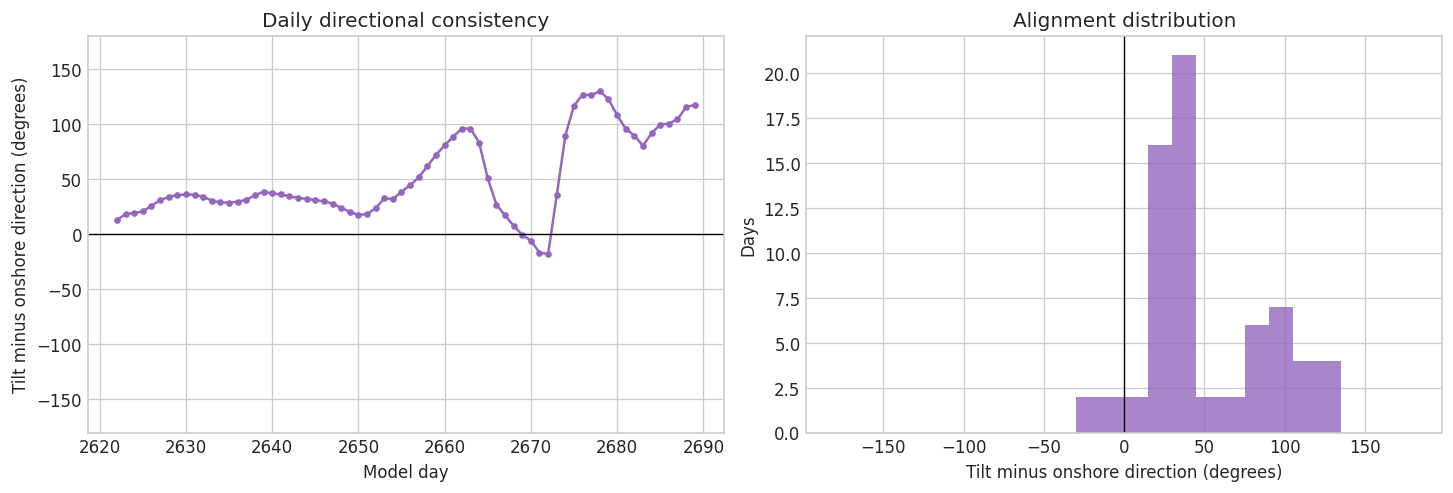

,value
days_with_direction,68.000000
circular_mean_offset_deg,49.351770
resultant_length,0.796577
fraction_within_45deg_onshore,0.632353


In [8]:
ect.plot_daily_alignment(composite)
plt.show()

angles = np.deg2rad(composite.daily.tilt_minus_axis1_deg.dropna())
mean_vector = np.mean(np.exp(1j*angles)) if len(angles) else np.nan
display(pd.Series({
    'days_with_direction': len(angles),
    'circular_mean_offset_deg': np.degrees(np.angle(mean_vector)) if len(angles) else np.nan,
    'resultant_length': np.abs(mean_vector) if len(angles) else np.nan,
    'fraction_within_45deg_onshore': np.mean(np.abs(np.degrees(np.angle(np.exp(1j*angles)))) <= 45) if len(angles) else np.nan,
}).to_frame('value'))

## Daily and mean vertical centre structure

Thin lines are individual days; the heavy line is the mean fitted centre at each exact depth.

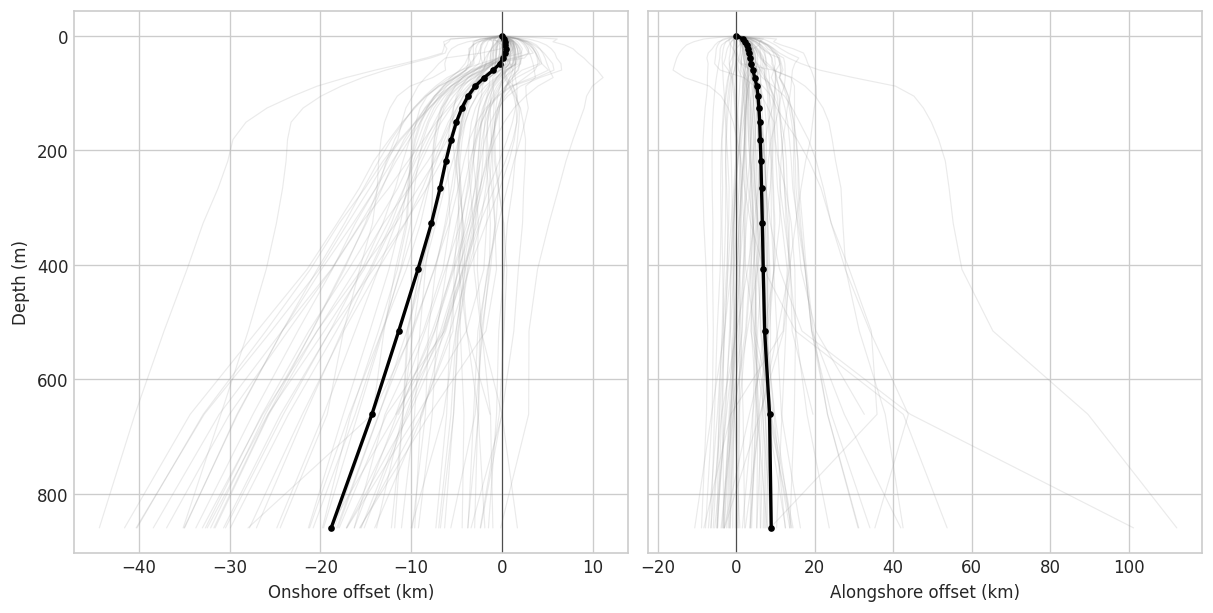

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, constrained_layout=True)
for _, part in composite.centres.groupby('Day'):
    axes[0].plot(part.axis1_offset, part.Depth, color='0.6', alpha=.2, lw=.7)
    axes[1].plot(part.axis2_offset, part.Depth, color='0.6', alpha=.2, lw=.7)
axes[0].plot(composite.centre_mean.axis1_offset, composite.depths, 'k.-', lw=2)
axes[1].plot(composite.centre_mean.axis2_offset, composite.depths, 'k.-', lw=2)
axis1 = 'Onshore' if COMPOSITE_FRAME == 'onshore' else 'Grid x'
axis2 = 'Alongshore' if COMPOSITE_FRAME == 'onshore' else 'Grid y'
axes[0].set(xlabel=f'{axis1} offset ({HORIZONTAL_UNITS})', ylabel='Depth (m)')
axes[1].set(xlabel=f'{axis2} offset ({HORIZONTAL_UNITS})')
for ax in axes:
    ax.axvline(0, color='0.3', lw=.7)
ax.invert_yaxis()
plt.show()

## Composite velocity sections

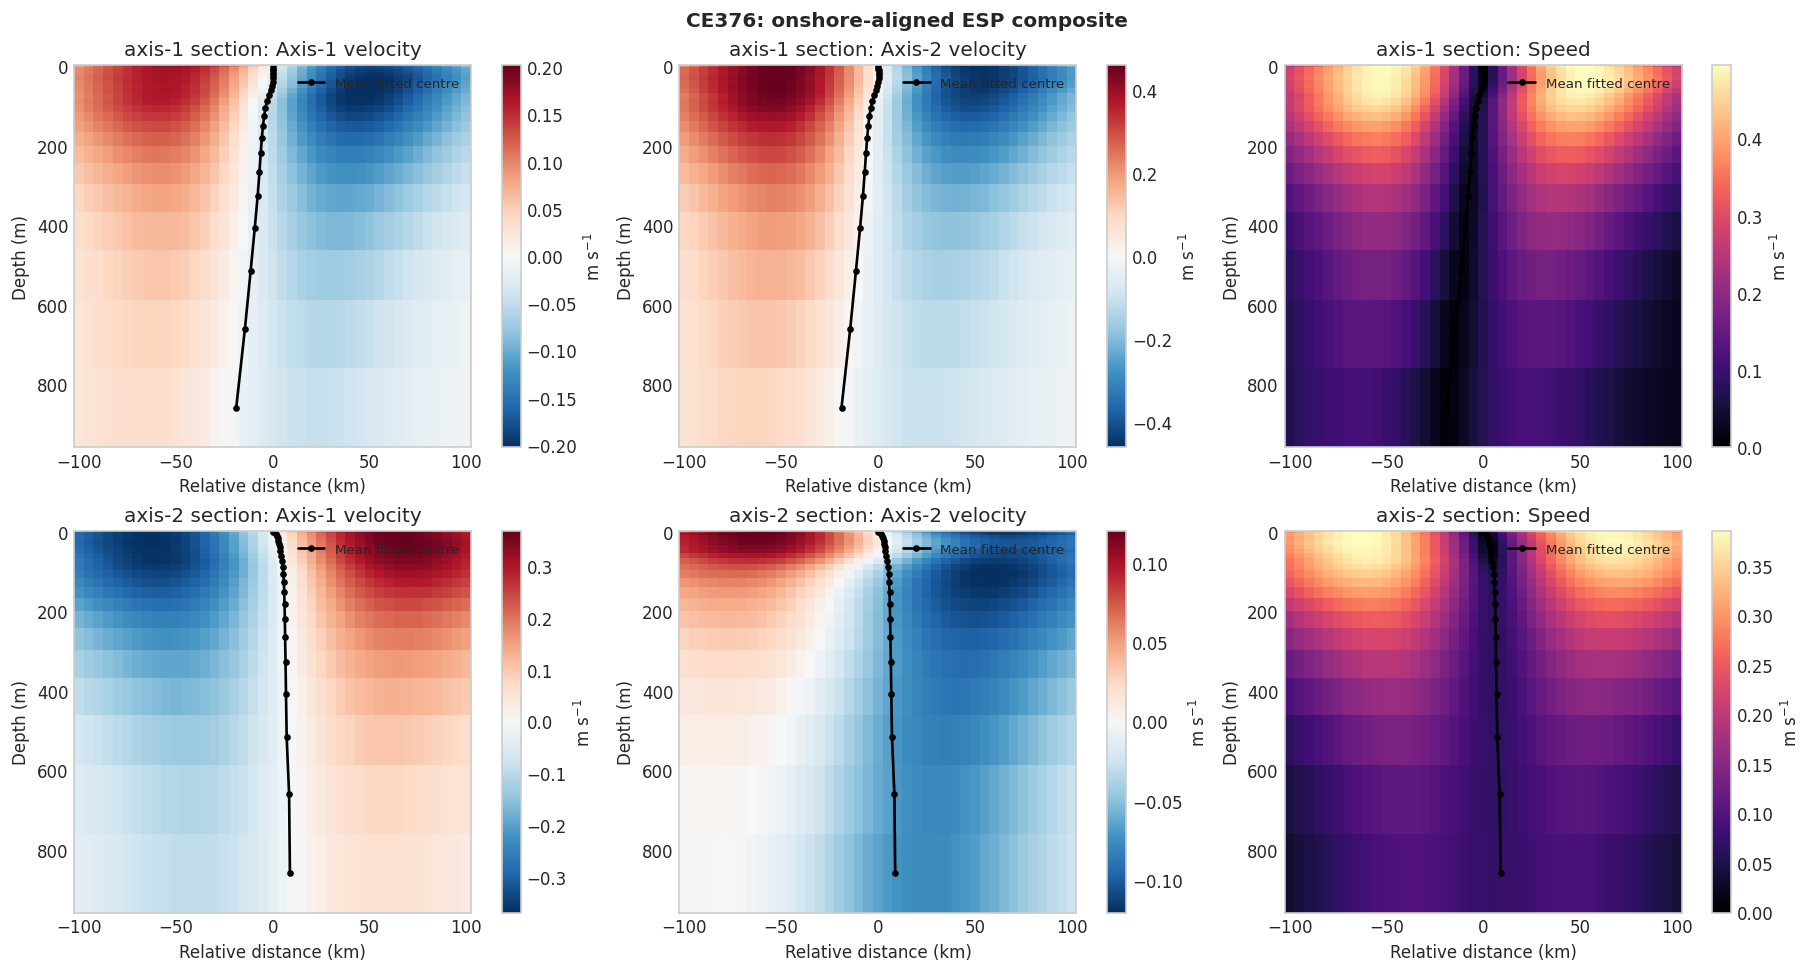

In [10]:
ect.plot_composite_sections(composite)
plt.show()

## Mean three-dimensional ESP velocity field

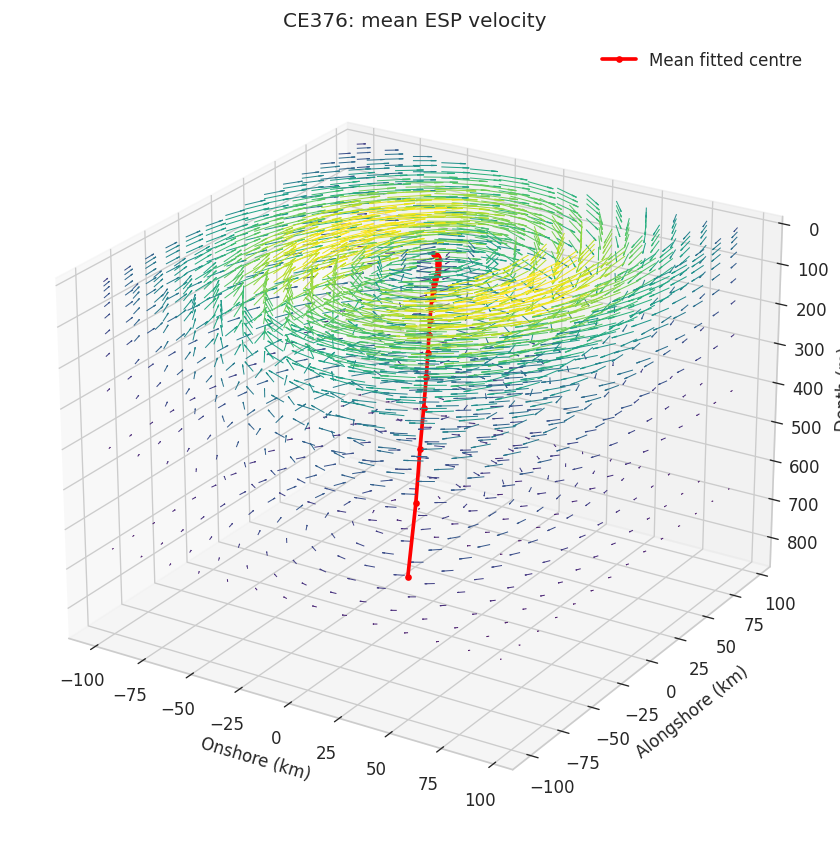

In [11]:
ect.plot_composite_3d(composite, xy_step=3, z_step=2)
plt.show()

## Extension to multi-eddy composites

The same reconstruction can later be applied to pooled eddy-days selected by region, polarity, Rossby number, PV regime or shear. For that comparison, use radius-normalised horizontal units, preserve equal weighting at the eddy level rather than letting long-lived eddies dominate, and bootstrap entire eddies—not individual days—to retain within-eddy dependence.